# <center>📊 Analyse Exploratoire des Données (EDA)</center>
<center><i>Prédiction du défaut de paiement sur carte de crédit</i></center>

---

Ce notebook réalise une **analyse exploratoire complète** du jeu de données `credit_card_default.csv`.
L'objectif est de comprendre la structure des données, identifier les valeurs aberrantes,
et mettre en évidence les variables les plus discriminantes pour la prédiction du défaut de paiement.

**Plan :**
1. Importation des librairies et du jeu de données
2. Aperçu et qualité des données
3. Statistiques descriptives
4. Analyse du taux de défaut global
5. Nettoyage et analyse par variables catégorielles
6. Analyse par statut de paiement
7. Analyse par montant facturé et montant payé


## 1. Importation des librairies et du fichier de données

On importe les librairies classiques d'analyse de données et de visualisation,
puis on charge le fichier CSV en supprimant la colonne de prédiction si elle est déjà présente.


In [2]:
# ── Librairies de manipulation de données ──────────────────────────────────
import pandas as pd                  # Chargement et manipulation des DataFrames
import numpy as np                   # Calculs numériques vectorisés

# ── Librairies de visualisation ─────────────────────────────────────────────
import matplotlib.pyplot as plt      # Graphiques de base
import matplotlib.gridspec as gridspec  # Mise en page avancée des subplots
import seaborn as sns                # Visualisations statistiques enrichies

# ── Suppression des warnings non critiques ──────────────────────────────────
import warnings
warnings.filterwarnings('ignore')    # Évite le bruit dans les sorties


In [4]:
# ── Chargement du fichier CSV ───────────────────────────────────────────────
df = pd.read_csv("credit_card_default.csv")

# Suppression de la colonne de prédictions préexistante si elle a été ajoutée
# par un pipeline précédent (évite une fuite de données dans l'analyse)
df = df.drop(columns=['predicted_default_payment_next_month'], errors='ignore')

# ── Options d'affichage pandas ──────────────────────────────────────────────
pd.set_option('display.max_columns', None)  # Afficher toutes les colonnes
pd.set_option('display.width', None)        # Pas de retour à la ligne forcé

# ── Dimensions du DataFrame ─────────────────────────────────────────────────
print(f"Lignes : {df.shape[0]} | Colonnes : {df.shape[1]}")


Lignes : 2965 | Colonnes : 25


## 2. Aperçu du DataFrame — 10 premières lignes

Affichage des premières lignes pour vérifier la structure des colonnes,
les types de données et la cohérence des valeurs.


In [5]:
# Aperçu des 10 premières lignes du DataFrame
# Permet de vérifier les noms de colonnes, les types et les valeurs brutes
df.head(10)


,id,limit_balance,sex,education_level,marital_status,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt_1,bill_amt_2,bill_amt_3,bill_amt_4,bill_amt_5,bill_amt_6,pay_amt_1,pay_amt_2,pay_amt_3,pay_amt_4,pay_amt_5,pay_amt_6,default_payment_next_month
0,27502.0,80000.0,1,6,1,54.0,0.0,0.0,0.0,0.0,0,0,61454.0,61808.0,62290.0,29296.0,26210.0,17643.0,2545.0,2208.0,1336.0,2232.0,542.0,348.0,1
1,26879.0,200000.0,1,4,1,49.0,0.0,0.0,0.0,0.0,0,0,49221.0,49599.0,50942.0,50146.0,50235.0,48984.0,1689.0,2164.0,2500.0,3480.0,2500.0,3000.0,0
2,18340.0,20000.0,2,6,2,22.0,0.0,0.0,0.0,0.0,0,0,19568.0,19420.0,15535.0,1434.0,500.0,0.0,4641.0,1019.0,900.0,0.0,1500.0,0.0,1
3,13692.0,260000.0,2,4,2,33.0,0.0,0.0,0.0,0.0,0,0,18457.0,22815.0,27086.0,27821.0,30767.0,29890.0,5000.0,5000.0,1137.0,5000.0,1085.0,5000.0,0
4,20405.0,150000.0,1,4,2,32.0,0.0,0.0,0.0,-1.0,0,0,159919.0,68686.0,161192.0,150464.0,143375.0,146411.0,4019.0,146896.0,157436.0,4600.0,4709.0,5600.0,0
5,3882.0,300000.0,2,4,2,32.0,0.0,0.0,0.0,0.0,0,-1,54053.0,65235.0,64747.0,65150.0,-450.0,700.0,15235.0,1491.0,1303.0,0.0,2000.0,1400.0,0
6,7227.0,130000.0,1,1,1,45.0,0.0,0.0,0.0,0.0,0,0,58180.0,59134.0,61156.0,62377.0,63832.0,65099.0,2886.0,2908.0,2129.0,2354.0,2366.0,2291.0,0
7,1379.0,200000.0,1,1,1,58.0,0.0,0.0,0.0,0.0,0,0,192461.0,195970.0,122214.0,124647.0,126921.0,129167.0,7822.0,4417.0,4446.0,4597.0,4677.0,4698.0,0
8,29477.0,500000.0,1,1,1,39.0,0.0,0.0,0.0,0.0,0,0,133598.0,167378.0,171106.0,174500.0,137406.0,204975.0,54209.0,4607.0,4603.0,5224.0,207440.0,7509.0,0
9,10643.0,230000.0,1,1,1,48.0,0.0,0.0,0.0,0.0,0,0,160879.0,161797.0,165107.0,105508.0,108101.0,110094.0,7000.0,6607.0,3773.0,4290.0,4164.0,2000.0,0


In [6]:
# Comptage des valeurs manquantes par colonne
# Une somme à 0 sur toutes les colonnes indique un dataset complet
print(df.isna().sum())


id                            0
limit_balance                 0
sex                           0
education_level               0
marital_status                0
age                           0
pay_0                         0
pay_2                         0
pay_3                         0
pay_4                         0
pay_5                         0
pay_6                         0
bill_amt_1                    0
bill_amt_2                    0
bill_amt_3                    0
bill_amt_4                    0
bill_amt_5                    0
bill_amt_6                    0
pay_amt_1                     0
pay_amt_2                     0
pay_amt_3                     0
pay_amt_4                     0
pay_amt_5                     0
pay_amt_6                     0
default_payment_next_month    0
dtype: int64


> ✅ **Aucune valeur manquante** n'est détectée dans le jeu de données.
Le dataset est complet : aucun traitement d'imputation n'est nécessaire à ce stade.


## 3. Statistiques descriptives

On examine les statistiques de chaque colonne (moyenne, écart-type, min/max, quartiles)
ainsi que les informations générales du DataFrame (types, mémoire utilisée).
Les colonnes `pay_0` à `pay_6` sont converties en `float` pour homogénéiser les types numériques.


In [9]:
# Statistiques descriptives : count, mean, std, min, quartiles, max
# Permet d'identifier les colonnes avec des distributions asymétriques
# ou des valeurs extrêmes (ex : bill_amt pouvant atteindre plusieurs centaines de milliers)
df.describe()


,id,limit_balance,sex,education_level,marital_status,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt_1,bill_amt_2,bill_amt_3,bill_amt_4,bill_amt_5,bill_amt_6,pay_amt_1,pay_amt_2,pay_amt_3,pay_amt_4,pay_amt_5,pay_amt_6,default_payment_next_month
count,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2.965000e+03,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000
mean,14945.556155,163369.308600,1.607757,1.849578,1.559865,35.193255,0.005059,-0.122428,-0.141653,-0.185160,-0.225295,-0.254637,52118.305228,50649.153120,48239.757504,44089.683305,40956.080607,39773.072513,6348.902867,6.272494e+03,5150.497133,4561.376054,4913.286678,5382.701518,0.214165
std,8700.288152,125030.415472,0.488333,0.778184,0.522317,9.109439,1.114395,1.180784,1.183630,1.178322,1.159003,1.167305,72328.670541,70785.001588,68145.710745,61907.454056,58271.904751,57303.488981,20885.735336,2.887967e+04,14287.079982,13281.499599,16734.340778,17275.953029,0.410311
min,29.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-11545.000000,-67526.000000,-25443.000000,-46627.000000,-46627.000000,-73895.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7499.000000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3958.000000,3390.000000,3302.000000,2582.000000,1958.000000,1430.000000,1013.000000,9.900000e+02,477.000000,313.000000,323.000000,173.000000,0.000000
50%,14782.000000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24257.000000,23111.000000,21520.000000,19894.000000,18814.000000,18508.000000,2234.000000,2.175000e+03,1994.000000,1600.000000,1646.000000,1615.000000,0.000000
75%,22571.000000,230000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69852.000000,67827.000000,63023.000000,58622.000000,53373.000000,52287.000000,5087.000000,5.000000e+03,4500.000000,4000.000000,4021.000000,4081.000000,0.000000
max,29995.000000,800000.000000,2.000000,6.000000,3.000000,69.000000,8.000000,7.000000,7.000000,8.000000,7.000000,7.000000,613860.000000,512650.000000,578971.000000,488808.000000,441981.000000,436172.000000,493358.000000,1.227082e+06,199209.000000,202076.000000,388071.000000,403500.000000,1.000000


In [10]:
# Informations générales : types de données (dtype), valeurs non-nulles, mémoire
# Utile pour détecter les colonnes mal typées (ex : int là où on attend float)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2965 entries, 0 to 2964
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          2965 non-null   float64
 1   limit_balance               2965 non-null   float64
 2   sex                         2965 non-null   int64  
 3   education_level             2965 non-null   int64  
 4   marital_status              2965 non-null   int64  
 5   age                         2965 non-null   float64
 6   pay_0                       2965 non-null   float64
 7   pay_2                       2965 non-null   float64
 8   pay_3                       2965 non-null   float64
 9   pay_4                       2965 non-null   float64
 10  pay_5                       2965 non-null   int64  
 11  pay_6                       2965 non-null   int64  
 12  bill_amt_1                  2965 non-null   float64
 13  bill_amt_2                  2965 non-null   

In [11]:
# Les colonnes pay_0 à pay_6 encodent le statut de remboursement mensuel
# Elles sont parfois lues en int ; on les convertit en float pour homogénéité
# avec les autres colonnes numériques et éviter des erreurs de calcul ultérieures
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']
df[pay_cols] = df[pay_cols].astype(float)

# Vérification : on confirme que les colonnes sont bien en float64
print(df.dtypes)


id                            float64
limit_balance                 float64
sex                             int64
education_level                 int64
marital_status                  int64
age                           float64
pay_0                         float64
pay_2                         float64
pay_3                         float64
pay_4                         float64
pay_5                         float64
pay_6                         float64
bill_amt_1                    float64
bill_amt_2                    float64
bill_amt_3                    float64
bill_amt_4                    float64
bill_amt_5                    float64
bill_amt_6                    float64
pay_amt_1                     float64
pay_amt_2                     float64
pay_amt_3                     float64
pay_amt_4                     float64
pay_amt_5                     float64
pay_amt_6                     float64
default_payment_next_month      int64
dtype: object


## 4. Calcul et affichage du taux de défaut global

Le **taux de défaut** correspond à la proportion de clients ayant fait défaut
sur leur paiement le mois suivant (`default_payment_next_month = 1`).
C'est la variable cible de notre analyse.


  Pas de défaut (0) : 2330 (78.6%)
  Défaut        (1) : 635 (21.4%)


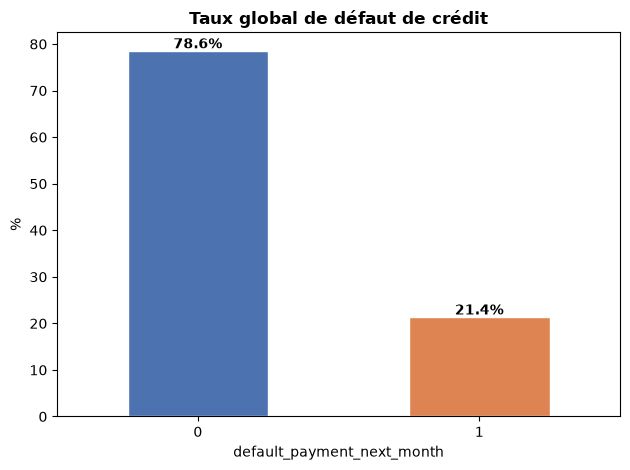

In [12]:
# ── Comptage brut des classes ───────────────────────────────────────────────
# 0 = pas de défaut | 1 = défaut le mois suivant
defaut = df['default_payment_next_month'].value_counts()
print(f"  Pas de défaut (0) : {defaut[0]} ({defaut[0]/len(df)*100:.1f}%)")
print(f"  Défaut        (1) : {defaut[1]} ({defaut[1]/len(df)*100:.1f}%)")

# ── Calcul du taux en pourcentage (normalize=True → proportions entre 0 et 1) ─
taux = df['default_payment_next_month'].value_counts(normalize=True) * 100

# ── Graphique en barres ──────────────────────────────────────────────────────
ax = taux.plot(kind='bar', color=['#4C72B0', '#DD8452'], edgecolor='white')

# Ajout des étiquettes de pourcentage au-dessus de chaque barre
for i, v in enumerate(taux.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.title("Taux global de défaut de crédit", fontweight='bold')
plt.ylabel("%")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 4.1 Taux de défaut par variable socio-démographique (brut)

On segmente le taux de défaut selon le **sexe**, le **niveau d'éducation** et
le **statut marital**. Cette première visualisation utilise les codes numériques bruts.



--- Sexe ---
  1 : 22.5%
  2 : 20.7%

--- Éducation ---
  0 : 0.0%
  1 : 17.0%
  2 : 24.4%
  3 : 23.4%
  4 : 0.0%
  5 : 4.2%
  6 : 50.0%

--- Statut marital ---
  0 : 0.0%
  1 : 22.7%
  2 : 20.5%
  3 : 17.1%


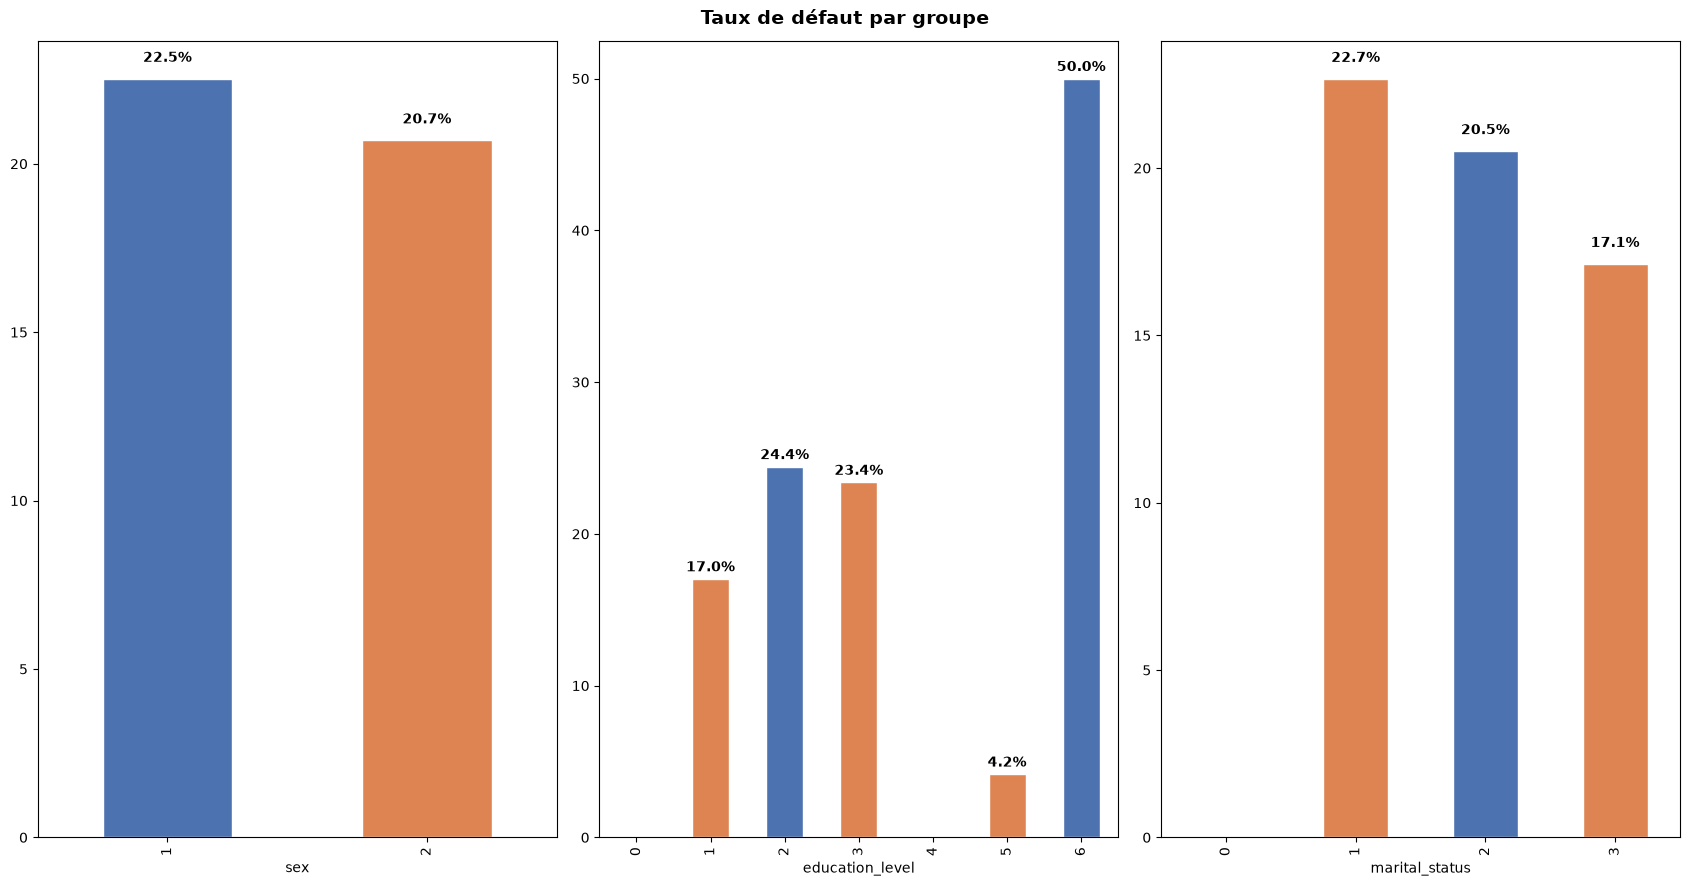

In [13]:
# ── Variables catégorielles à analyser ──────────────────────────────────────
cat_vars = {
    'Sexe':           'sex',
    'Éducation':      'education_level',
    'Statut marital': 'marital_status',
}

# Affichage textuel du taux de défaut moyen par modalité
# groupby + mean() sur la variable cible binaire donne directement la proportion de défauts
for label, col in cat_vars.items():
    print(f"\n--- {label} ---")
    g = df.groupby(col)['default_payment_next_month'].mean()
    for k, v in g.items():
        print(f"  {k} : {v*100:.1f}%")

# ── Graphiques en barres (1 par variable) ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 9))
fig.suptitle("Taux de défaut par groupe", fontsize=14, fontweight='bold')

groupes = {
    'Sexe':           'sex',
    'Éducation':      'education_level',
    'Statut marital': 'marital_status',
}

for ax, (label, col) in zip(axes, groupes.items()):
    # value_counts(normalize=True).unstack() → tableau croisé 0/1 en proportions
    # On sélectionne la colonne [1] = taux de défaut
    taux = df.groupby(col)['default_payment_next_month'].value_counts(normalize=True).unstack() * 100
    taux[1].plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white')
    # Annotation des valeurs sur les barres
    for i, v in enumerate(taux[1].values):
        ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


### 4.2 Même analyse avec des étiquettes lisibles

On remplace les codes numériques par des libellés explicites grâce à des dictionnaires de mapping,
pour rendre les graphiques directement interprétables.


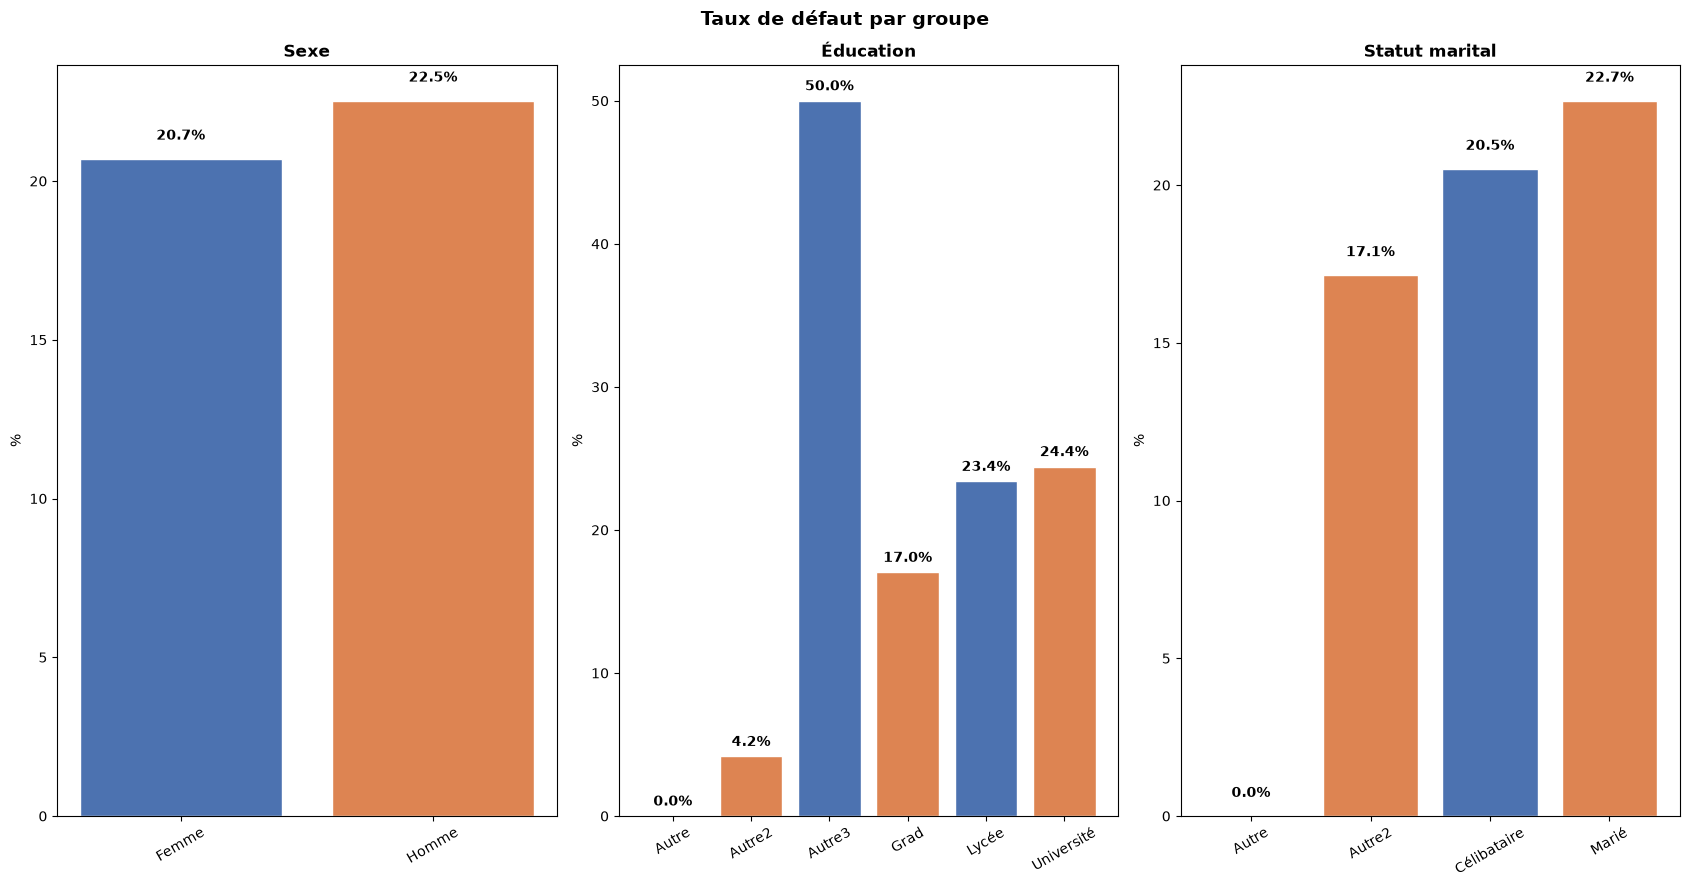

In [14]:
# ── Dictionnaires de mapping : code numérique → libellé lisible ─────────────
sex_map = {1: 'Homme', 2: 'Femme'}
edu_map = {1: 'Grad', 2: 'Université', 3: 'Lycée', 4: 'Autre', 5: 'Autre2', 6: 'Autre3'}
mar_map = {0: 'Autre', 1: 'Marié', 2: 'Célibataire', 3: 'Autre2'}

# ── Mise en place de la figure (3 sous-graphes côte à côte) ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 9))
fig.suptitle("Taux de défaut par groupe", fontsize=14, fontweight='bold')

groupes = {
    'Sexe': ('sex', sex_map),
    'Éducation': ('education_level', edu_map),
    'Statut marital': ('marital_status', mar_map),
}

for ax, (label, (col, mapping)) in zip(axes, groupes.items()):
    # On remplace les codes par les libellés lisibles avant de calculer le taux
    labels = df[col].map(mapping)
    taux = df.assign(_label=labels).groupby('_label')['default_payment_next_month'].mean() * 100
    taux = taux.sort_index()

    bars = ax.bar(taux.index, taux.values, color=['#4C72B0', '#DD8452'], edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('%')
    ax.set_xlabel('')
    ax.set_xticks(range(len(taux.index)))
    ax.set_xticklabels(taux.index, rotation=30)

    for bar, v in zip(bars, taux.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f"{v:.1f}%",
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
### Interprétation

Ce graphique montre que le taux de défaut varie selon les catégories sociales et démographiques.
Les différences observées permettent d’identifier les segments plus risqués et orientent la sélection des variables les plus discriminantes pour la modélisation.

Les codes numériques ont été remplacés par des libellés lisibles pour faciliter l’interprétation métier du résultat.


### 4.3 Distribution des modalités — identification des valeurs aberrantes

Avant de filtrer, on examine la fréquence de chaque modalité pour justifier les suppressions.


In [15]:
# ── Distribution des modalités AVANT nettoyage ──────────────────────────────
# On identifie les codes non documentés (0, 4, 5, 6 pour education ; 0, 3 pour marital)
print("=== education_level (avant) ===")
print(df['education_level'].value_counts())

print("\n=== marital_status (avant) ===")
print(df['marital_status'].value_counts())

# ── Suppression des lignes avec des modalités non documentées ────────────────
# Ces codes n'ont pas de signification connue et représentent très peu de lignes
df = df[~df['education_level'].isin([0, 4, 5, 6])]
df = df[~df['marital_status'].isin([0, 3])]

# ── Vérification APRÈS nettoyage ─────────────────────────────────────────────
print("\n=== education_level (après) ===")
print(df['education_level'].value_counts())

print("\n=== marital_status (après) ===")
print(df['marital_status'].value_counts())


=== education_level (avant) ===
education_level
2    1400
1    1039
3     483
5      24
4      13
6       4
0       2
Name: count, dtype: int64

=== marital_status (avant) ===
marital_status
2    1594
1    1332
3      35
0       4
Name: count, dtype: int64

=== education_level (après) ===
education_level
2    1383
1    1036
3     464
Name: count, dtype: int64

=== marital_status (après) ===
marital_status
2    1572
1    1311
Name: count, dtype: int64


### 🧹 Nettoyage des variables catégorielles

Après analyse de la distribution des modalités, on observe que :

- **`education_level`** : les codes `0`, `4`, `5` et `6` ne correspondent à aucune catégorie documentée
  et représentent un nombre de lignes négligeable. On les supprime.
- **`marital_status`** : les codes `0` et `3` sont absents de la définition officielle du dataset
  et sont également très peu représentés. On les supprime.

Ce nettoyage préserve l'intégrité de l'analyse tout en évitant des catégories non interprétables.


## 5. Statistiques descriptives après nettoyage

On réexamine les statistiques du DataFrame une fois les lignes aberrantes supprimées,
afin de s'assurer que la distribution globale n'est pas altérée.


In [16]:
# Statistiques descriptives sur le DataFrame nettoyé
# On s'assure que la distribution des variables numériques clés
# (limit_bal, bill_amt, pay_amt) est restée cohérente après suppression des lignes
df.describe()


,id,limit_balance,sex,education_level,marital_status,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt_1,bill_amt_2,bill_amt_3,bill_amt_4,bill_amt_5,bill_amt_6,pay_amt_1,pay_amt_2,pay_amt_3,pay_amt_4,pay_amt_5,pay_amt_6,default_payment_next_month
count,2883.000000,2883.000000,2883.000000,2883.000000,2883.000000,2883.000000,2883.000000,2883.000000,2883.000000,2883.000000,2883.000000,2883.000000,2883.000000,2883.000000,2883.000000,2883.000000,2883.000000,2883.000000,2883.000000,2.883000e+03,2883.000000,2883.000000,2883.000000,2883.000000,2883.000000
mean,14888.704475,163926.465487,1.610475,1.801596,1.545265,35.104752,0.005203,-0.120708,-0.136316,-0.179327,-0.218176,-0.246965,51952.291710,50662.701006,48279.634409,44337.977801,41250.812695,40021.985432,6415.375997,6.228128e+03,5133.958724,4597.062088,4861.337843,5409.406868,0.217135
std,8717.999891,125501.288262,0.487727,0.693609,0.498033,9.069788,1.117479,1.185442,1.188282,1.184020,1.162950,1.171036,72354.109782,70924.929165,68323.280329,62384.341210,58733.827162,57579.946230,21143.538081,2.906802e+04,14126.862175,13346.155684,16013.863155,17242.763489,0.412367
min,29.000000,10000.000000,1.000000,1.000000,1.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-11545.000000,-67526.000000,-25443.000000,-46627.000000,-46627.000000,-73895.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7394.000000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3842.500000,3399.000000,3347.500000,2633.000000,2034.500000,1478.000000,1003.500000,9.670000e+02,472.000000,316.000000,324.500000,184.000000,0.000000
50%,14735.000000,140000.000000,2.000000,2.000000,2.000000,33.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24114.000000,23075.000000,21488.000000,19896.000000,18996.000000,18586.000000,2233.000000,2.190000e+03,2000.000000,1616.000000,1651.000000,1686.000000,0.000000
75%,22509.500000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69077.500000,67346.000000,62676.500000,58527.500000,53569.000000,52522.500000,5157.500000,5.004500e+03,4509.000000,4022.500000,4080.500000,4148.500000,0.000000
max,29995.000000,800000.000000,2.000000,3.000000,2.000000,69.000000,8.000000,7.000000,7.000000,8.000000,7.000000,7.000000,613860.000000,512650.000000,578971.000000,488808.000000,441981.000000,436172.000000,493358.000000,1.227082e+06,199209.000000,202076.000000,388071.000000,403500.000000,1.000000


### 5.1 Taux de défaut par groupe — après nettoyage

Les graphiques ci-dessous affichent le taux de défaut par catégorie
**après suppression des modalités non documentées**.
Les résultats sont désormais stables et interprétables.



--- Sexe ---
  Femme : 21.0%
  Homme : 22.8%

--- Éducation ---
  Grad : 17.1%
  Lycée : 24.1%
  Université : 24.4%

--- Statut marital ---
  Célibataire : 20.7%
  Marié : 22.9%


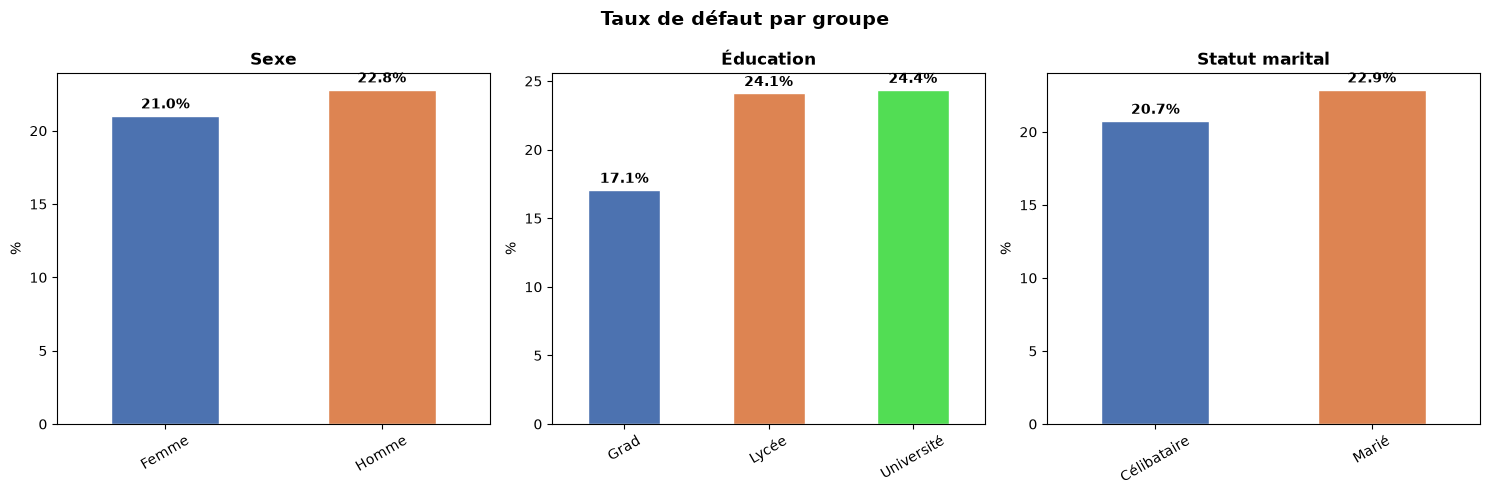

In [17]:
# ── Import matplotlib (idempotent si déjà importé) ──────────────────────────
import matplotlib.pyplot as plt

# ── Mappings code → libellé (version post-nettoyage : edu réduit à 3 classes) ─
sex_map = {1: 'Homme',      2: 'Femme'}
edu_map = {1: 'Grad',       2: 'Université', 3: 'Lycée'}  # codes 4/5/6 supprimés
mar_map = {1: 'Marié',      2: 'Célibataire'}              # codes 0/3 supprimés

groupes = {
    'Sexe':           ('sex',             sex_map),
    'Éducation':      ('education_level', edu_map),
    'Statut marital': ('marital_status',  mar_map),
}

# ── Résumé textuel ───────────────────────────────────────────────────────────
# .map(mapping) remplace les codes par les libellés avant le groupby
# .mean() sur la variable cible binaire = proportion de défauts
for label, (col, mapping) in groupes.items():
    print(f"\n--- {label} ---")
    g = df.groupby(df[col].map(mapping))['default_payment_next_month'].mean() * 100
    for k, v in g.items():
        print(f"  {k} : {v:.1f}%")

# ── Graphiques ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Taux de défaut par groupe", fontsize=14, fontweight='bold')

for ax, (label, (col, mapping)) in zip(axes, groupes.items()):
    taux = df.groupby(df[col].map(mapping))['default_payment_next_month'].mean() * 100
    taux.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452', '#52DD54'], edgecolor='white')
    # Annotation des valeurs au-dessus de chaque barre
    for i, v in enumerate(taux.values):
        ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel("%")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 6. Analyse par statut de paiement (`pay_0` à `pay_6`)

Les variables `pay_0` à `pay_6` encodent l'historique de remboursement sur les 6 derniers mois :
- `-2` : pas de consommation
- `-1` : compte soldé (payé intégralement)
- `0`  : utilisation du crédit renouvelable
- `1` à `8` : retard de paiement en mois

On s'attend à ce qu'un retard croissant soit fortement corrélé au taux de défaut.


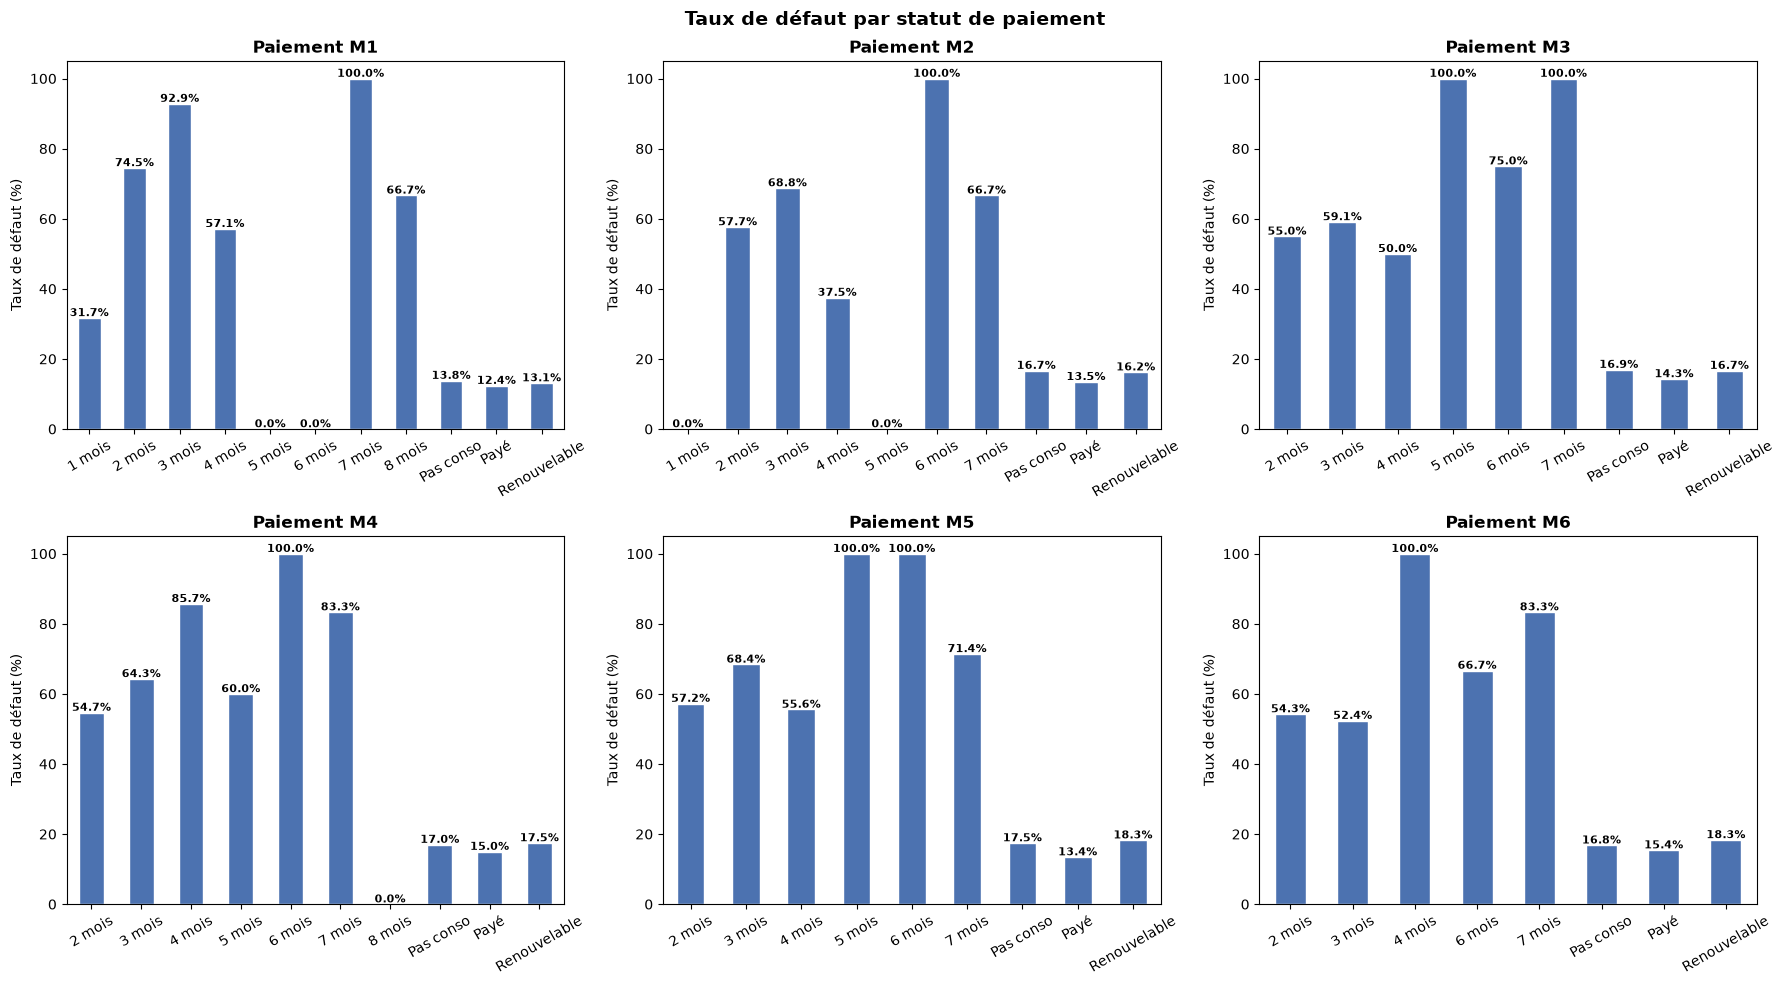

In [18]:
# ── Dictionnaire des colonnes de statut de paiement ─────────────────────────
# pay_0 = mois le plus récent (M1), pay_6 = il y a 6 mois (M6)
# Note : pay_1 est absent du dataset original
pay_cols = {
    'Paiement M1': 'pay_0',
    'Paiement M2': 'pay_2',
    'Paiement M3': 'pay_3',
    'Paiement M4': 'pay_4',
    'Paiement M5': 'pay_5',
    'Paiement M6': 'pay_6',
}

# ── Mapping des codes de statut de paiement ──────────────────────────────────
# -2 : pas de consommation ce mois | -1 : solde intégralement réglé
#  0 : utilisation du crédit renouvelable | 1–8 : retard en mois
pay_map = {
    -2: 'Pas conso',
    -1: 'Payé',
     0: 'Renouvelable',
     1: '1 mois',
     2: '2 mois',
     3: '3 mois',
     4: '4 mois',
     5: '5 mois',
     6: '6 mois',
     7: '7 mois',
     8: '8 mois',
}

# ── Grille de graphiques 2×3 (un par mois) ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Taux de défaut par statut de paiement", fontsize=14, fontweight='bold')

for ax, (label, col) in zip(axes.flatten(), pay_cols.items()):
    # Regroupement par statut de paiement (libellés lisibles via pay_map)
    taux = df.groupby(df[col].map(pay_map))['default_payment_next_month'].mean() * 100
    taux.plot(kind='bar', ax=ax, color='#4C72B0', edgecolor='white')
    # Annotation des valeurs sur chaque barre (fontsize réduit pour éviter le chevauchement)
    for i, v in enumerate(taux.values):
        ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=8, fontweight='bold')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel("Taux de défaut (%)")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


**Insight :** Le statut de paiement est le prédicteur le plus fort du défaut. Un retard de 2+ mois indique un risque multiplié par 5+. Cette variable sera centrale dans le modèle.

---

## 7. Analyse par montant facturé (`bill_amt_1` à `bill_amt_6`)

On découpe chaque montant facturé en **5 tranches** (`pd.cut`) et on calcule le taux de défaut
par tranche. L'objectif est de déterminer si les montants élevés ou faibles augmentent le risque.

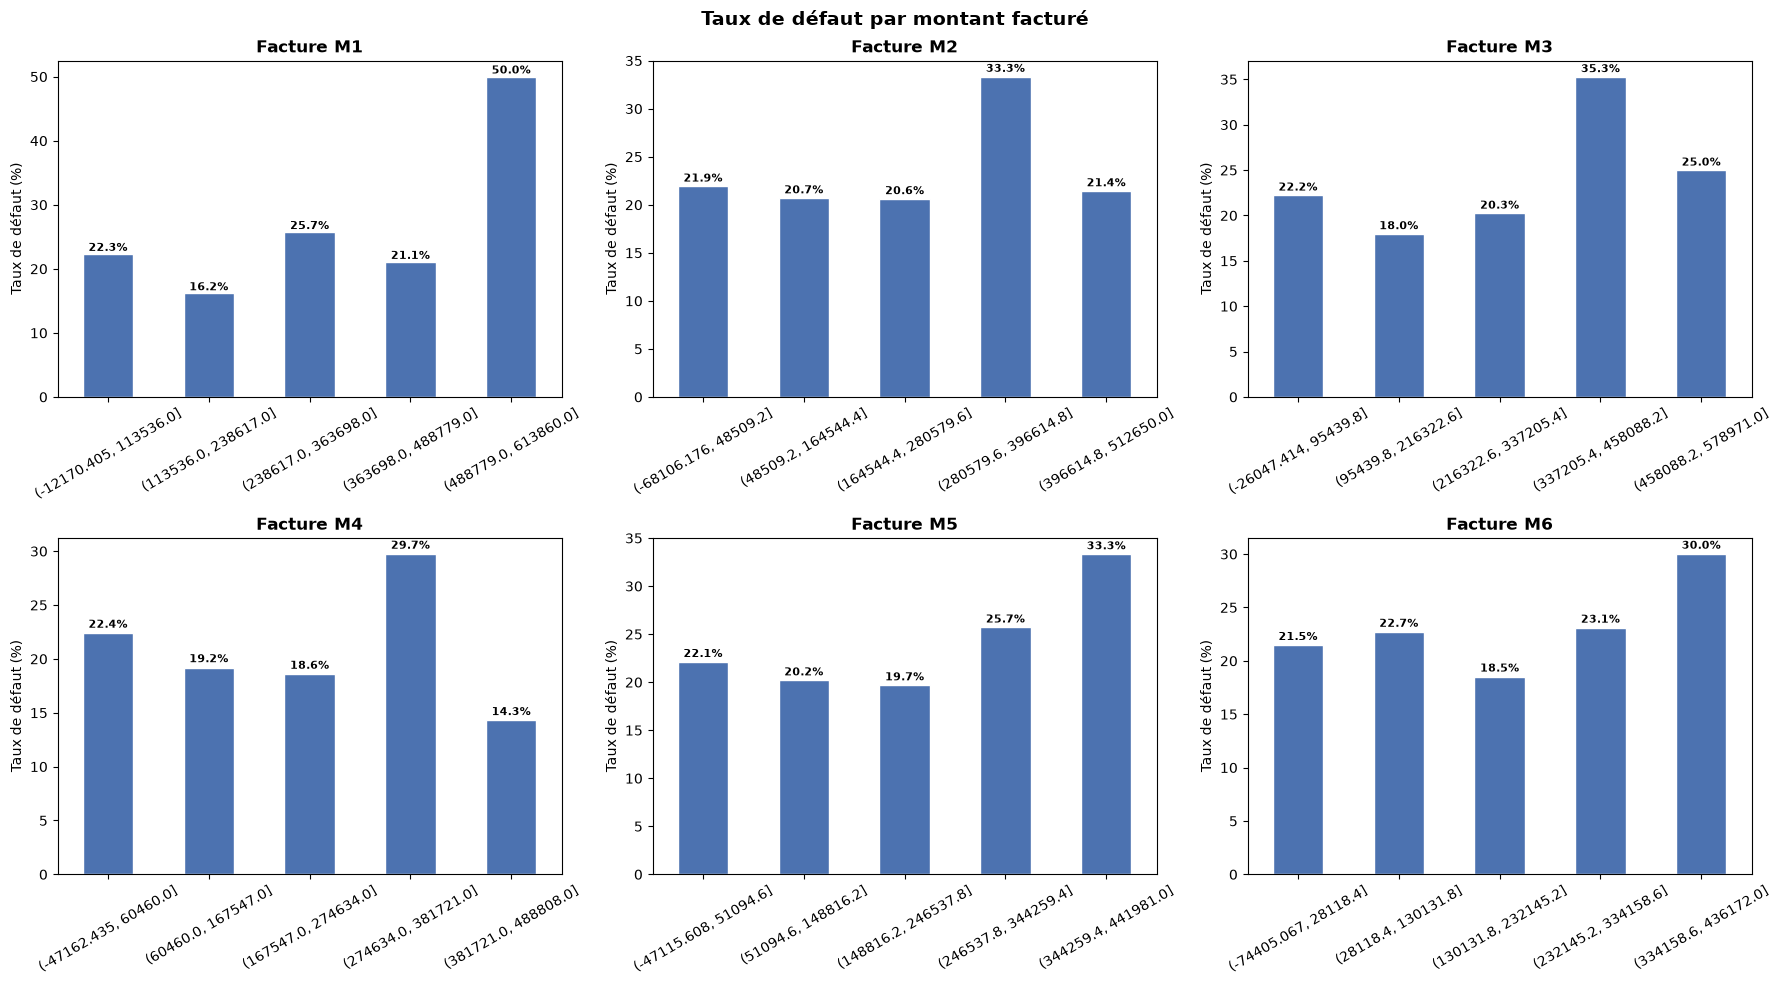

In [19]:
# ── Dictionnaire des colonnes de montant facturé ─────────────────────────────
# bill_amt_1 = solde dû le mois le plus récent, bill_amt_6 = il y a 6 mois
bill_cols = {
    'Facture M1': 'bill_amt_1',
    'Facture M2': 'bill_amt_2',
    'Facture M3': 'bill_amt_3',
    'Facture M4': 'bill_amt_4',
    'Facture M5': 'bill_amt_5',
    'Facture M6': 'bill_amt_6',
}

# ── Grille 2×3 ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Taux de défaut par montant facturé", fontsize=14, fontweight='bold')

for ax, (label, col) in zip(axes.flatten(), bill_cols.items()):
    # pd.cut() découpe la variable continue en 5 tranches d'amplitude égale
    # Permet de visualiser une tendance linéaire éventuelle avec le montant
    df['bin'] = pd.cut(df[col], bins=5)
    taux = df.groupby('bin')['default_payment_next_month'].mean() * 100
    taux.plot(kind='bar', ax=ax, color='#4C72B0', edgecolor='white')
    for i, v in enumerate(taux.values):
        ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=8, fontweight='bold')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel("Taux de défaut (%)")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=30)

# Suppression de la colonne temporaire 'bin' après usage
df.drop(columns=['bin'], inplace=True)
plt.tight_layout()
plt.show()


## 8. Analyse par montant payé (`pay_amt_1` à `pay_amt_6`)

On examine de la même façon le **montant effectivement remboursé** chaque mois.
Un faible remboursement relatif au solde dû est généralement un signal de risque élevé.


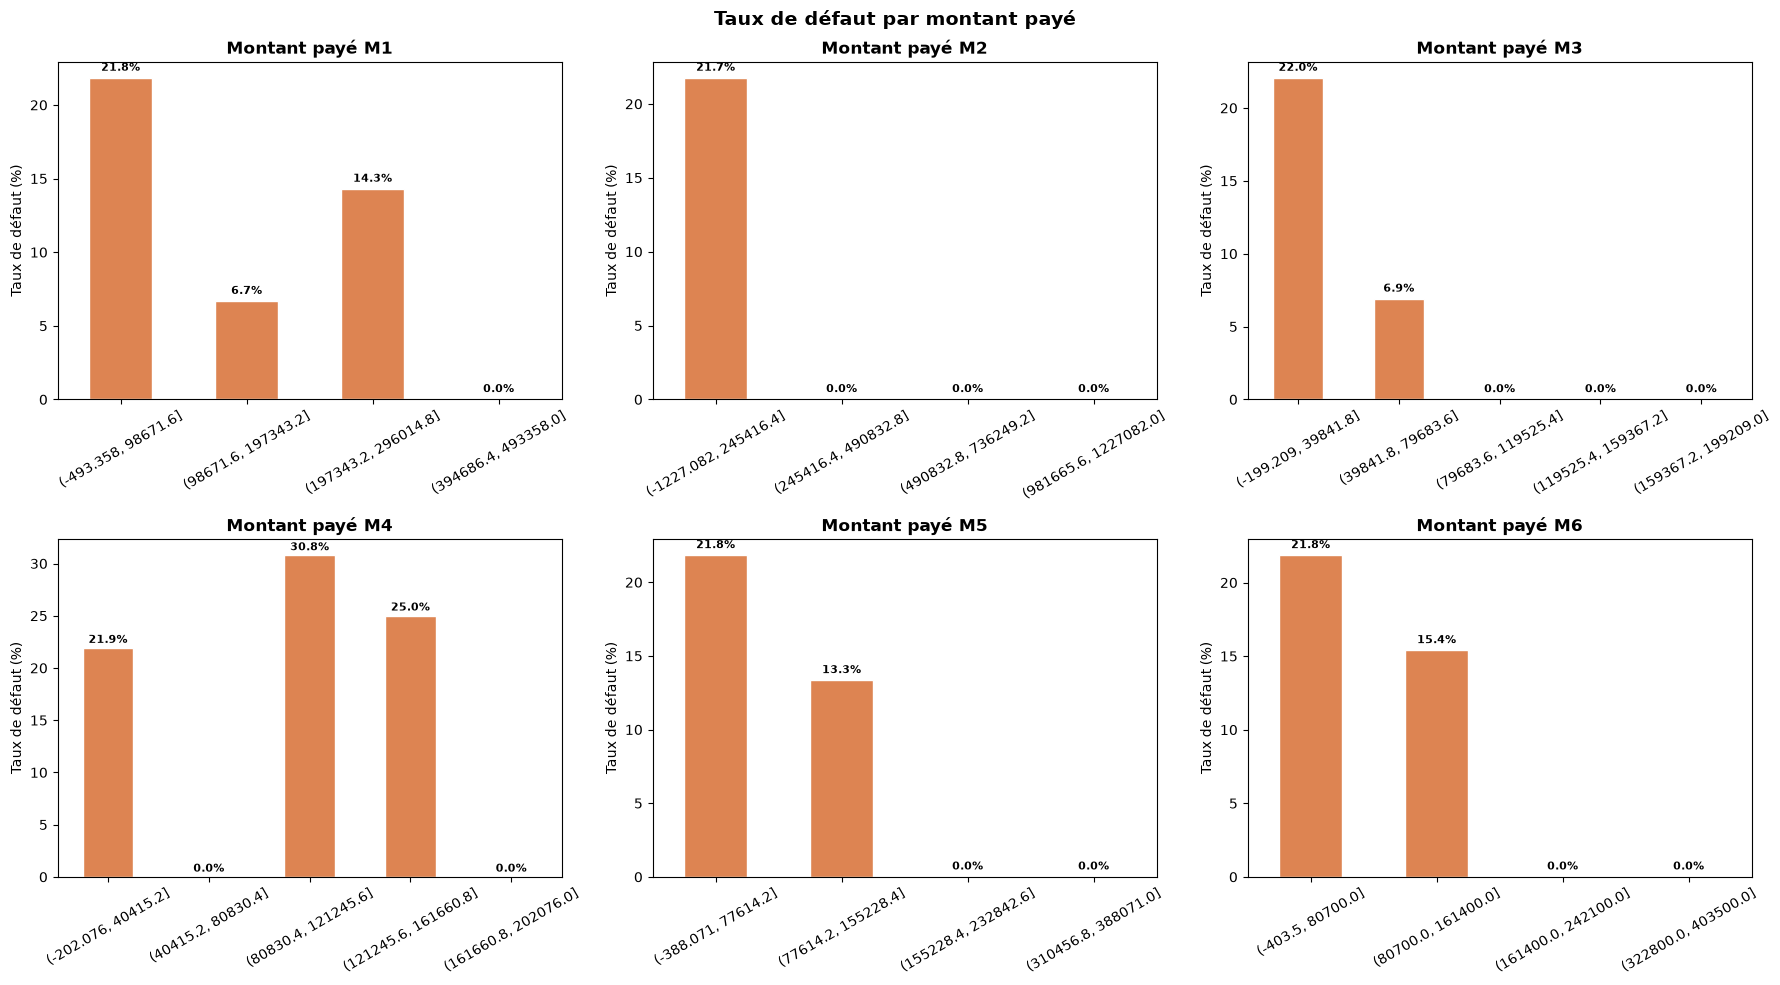

In [18]:
# ── Dictionnaire des colonnes de montant payé ────────────────────────────────
# pay_amt_1 = montant remboursé le mois le plus récent, pay_amt_6 = il y a 6 mois
pay_amt_cols = {
    'Montant payé M1': 'pay_amt_1',
    'Montant payé M2': 'pay_amt_2',
    'Montant payé M3': 'pay_amt_3',
    'Montant payé M4': 'pay_amt_4',
    'Montant payé M5': 'pay_amt_5',
    'Montant payé M6': 'pay_amt_6',
}

# ── Grille 2×3 ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Taux de défaut par montant payé", fontsize=14, fontweight='bold')

for ax, (label, col) in zip(axes.flatten(), pay_amt_cols.items()):
    # Même approche que pour bill_amt : discrétisation en 5 tranches égales
    # Un faible montant remboursé est généralement un signal de risque élevé
    df['bin'] = pd.cut(df[col], bins=5)
    taux = df.groupby('bin')['default_payment_next_month'].mean() * 100
    taux.plot(kind='bar', ax=ax, color='#DD8452', edgecolor='white')  # orange pour différencier
    for i, v in enumerate(taux.values):
        ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=8, fontweight='bold')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel("Taux de défaut (%)")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=30)

# Nettoyage de la colonne temporaire 'bin'
df.drop(columns=['bin'], inplace=True)
plt.tight_layout()
plt.show()


---

## 🎯 Conclusions

**Taux de défaut :** 21 % — déséquilibre modéré

**Variable clé :** Statut de paiement — un retard ≥ 2 mois augmente drastiquement le risque

**Variables secondaires :** Démographie (sexe, éducation) — faible mais mesurable

**Données :** Distribution asymétrique → normalisation recommandée

---
**Approche :** Pipeline ML avec sélection des features basée sur le paiement et normalisation logarithmique.